In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
file_path = "../data/raw/TREC-05.csv"
df = pd.read_csv(
    file_path,
    sep=',',              # Eğer virgül değilse burayı '\t' yapmayı dene
    quotechar='"',         # Tırnak içindeki metinleri tek bir blok say
    on_bad_lines='warn',   # Bozuk satırları bize rapor et ama geç
    engine='python',
    encoding='latin-1'    # Mail verilerinde genelde utf-8 yerine latin-1 kullanılır
)
# Kontrol etmek için:
print("Sütun isimleri:", df.columns)
# Sadece sayı olanları tut, metinleri temizle (Eğer hala kayma varsa)
df = df[df['label'].isin(['0', '1', 0, 1])] 
df['label'] = df['label'].astype(int)

print("\nDüzelmiş Label Dağılımı:")
print(df['label'].value_counts())

C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 12509: field larger than field limit (131072)

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 13101: field larger than field limit (131072)

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 13120: ',' expected after '"'

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 13124: ',' expected after '"'

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 23788: field larger than field limit (131072)

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.py:2: ParserWarning: Skipping line 24116: field larger than field limit (131072)

  df = pd.read_csv(
C:\Users\msozg\AppData\Local\Temp\ipykernel_3996\1038305267.

Sütun isimleri: Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

Düzelmiş Label Dağılımı:
label
0    32278
1    22932
Name: count, dtype: int64


In [4]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr PW: bnaweb22 -----O...,0,1
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,0
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,1
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald, We are currently trading under GT...",0,0
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 55210 entries, 0 to 59029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    55194 non-null  str  
 1   receiver  53439 non-null  str  
 2   date      53879 non-null  str  
 3   subject   53892 non-null  str  
 4   body      55209 non-null  str  
 5   label     55210 non-null  int64
 6   urls      55210 non-null  str  
dtypes: int64(1), str(6)
memory usage: 3.4 MB


In [6]:
df.isna().sum()

sender        16
receiver    1771
date        1331
subject     1318
body           1
label          0
urls           0
dtype: int64

In [7]:
df[df["receiver"].isna()].head()

,sender,receiver,date,subject,body,label,urls
176,winningluckyday09@handbag.com,NaN,"Thu, 05 Jul 2001 19:44:50 +0100",Congratulation You Have Won...,Congratulation You Have Won...\n\nLUCKYDAY ...,1,1
235,Neateye <NitaiGouranga@aol.com>,NaN,"Fri, 06 Jul 2001 09:24:36 -0000",Gouranga,Call out Gouranga be happy!!!\nGouranga Gouran...,1,0
278,mrsmith <carpenter_smith@yahoo.com>,NaN,"Fri, 06 Jul 2001 17:54:17 +0100",END OF YEAR LOTTERY AWARD NOTIFICATION.,\nBRITISH LOTTERY HEADQUARTERS:\nCUSTOMER SERV...,1,1
340,lotterypromo <award_prize_dept@yahoo.com>,NaN,"Sat, 07 Jul 2001 18:10:59 -0500",Congratulations!,\nINTERNATIONAL/PRIZE AWARD DEPT\nREF:PL2/2093...,1,1
347,mungthong2hand,NaN,NaN,ÃÃÃÃÂ´ÃÂ»ÃÃ£ÃÃÃ¨ 2548 Â»ÃÃ£ÃÃÃ¨Ã Â¡...,=?ISO-8859-1?Q?=A7=E4=C1=E8=E4=B4=E9=E3=AA=E9...,1,0


In [8]:
df["receiver"] = df["receiver"].fillna("unknown_receiver")
df["date"] = df["date"].fillna("unknown_date")
df["subject"] = df["subject"].fillna("unknown_subject")
df["sender"] = df["sender"].fillna("unknown_sender")
df.dropna(subset=["body"], inplace=True)
df.isna().sum()

sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64

In [9]:
print(f"Dataset shape: {df.shape}")
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Size of Dataset is {df.size}")

Dataset shape: (55209, 7)
Dataset has 55209 rows and 7 columns.
Size of Dataset is 386463


In [10]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
duplicate_bodies = df.duplicated(subset=['body']).sum()
print(f"Aynı içeriğe sahip mail sayısı: {duplicate_bodies}")

Aynı içeriğe sahip mail sayısı: 0


In [13]:
df['label'].value_counts(normalize=True)

label
0    0.584651
1    0.415349
Name: proportion, dtype: float64

In [14]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr PW: bnaweb22 -----O...,0,1
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,0
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,1
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald, We are currently trading under GT...",0,0
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,0


In [15]:
import re
import string

from nltk.stem import PorterStemmer
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

stop_words = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

urgent_keywords = {
    "urgent",
    "immediately",
    "asap",
    "action required",
    "verify",
    "suspended",
    "deadline",
    "final notice",
    "account",
    "payment",
    "update",
}

url_pattern = re.compile(r"(https?://\\S+|www\\.\\S+)", flags=re.IGNORECASE)
html_pattern = re.compile(r"<[^>]+>")
punct_table = str.maketrans("", "", string.punctuation)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.translate(punct_table)
    tokens = [
        stemmer.stem(token)
        for token in text.split()
        if token not in stop_words and token.isalpha()
    ]
    return " ".join(tokens)

def contains_urgent_keyword(text: str) -> int:
    text = str(text).lower()
    for keyword in urgent_keywords:
        if " " in keyword:
            if keyword in text:
                return 1
        elif re.search(rf"\\b{re.escape(keyword)}\\b", text):
            return 1
    return 0

In [ ]:
df["subject"] = df["subject"].fillna("").astype(str)
df["body"] = df["body"].fillna("").astype(str)

raw_text = df["subject"] + " " + df["body"]

df["subject_exclamation_count"] = df["subject"].str.count("!")
df["body_exclamation_count"] = df["body"].str.count("!")
df["exclamation_count"] = df["subject_exclamation_count"] + df["body_exclamation_count"]

df["url_count"] = df["body"].str.count(url_pattern)
df["contains_urgent_word"] = raw_text.apply(contains_urgent_keyword)
df["body_len"] = df["body"].str.len()
df["is_html"] = df["body"].str.contains(html_pattern, regex=True).astype(int)

df["subject_clean"] = df["subject"].apply(clean_text)
df["body_clean"] = df["body"].apply(clean_text)
df["text_clean"] = (df["subject_clean"] + " " + df["body_clean"]).str.strip()

preview_cols = [
    "subject",
    "subject_clean",
    "body",
    "body_clean",
    "url_count",
    "contains_urgent_word",
    "body_len",
    "is_html",
    "exclamation_count",
]
df[preview_cols].head(3)

,subject,subject_clean,body,body_clean,url_count,contains_urgent_word,body_len,is_html,exclamation_count
0,"FW: June 29 -- BNA, Inc. Daily Labor Report",fw june bna daili labor report,User ID: enrondlr PW: bnaweb22 -----O...,user id enrondlr pw origin messag bna highligh...,0,0,16145,0,0
1,NGX failover plan.,ngx failov plan,"\nHi Chris, \n\nTonight we are rolling out a ...",hi chri tonight roll new report current jon ac...,0,0,539,0,1
2,RE: Intranet Site,intranet site,Rika r these new?\n\n -----Original Message---...,rika r new origin messag thoma paul d sent fri...,0,0,577,0,0


In [17]:
df.head()

,sender,receiver,date,subject,body,label,urls,subject_exclamation_count,body_exclamation_count,exclamation_count,url_count,contains_urgent_word,body_len,is_html,subject_clean,body_clean,text_clean
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr PW: bnaweb22 -----O...,0,1,0,0,0,0,0,16145,0,fw june bna daili labor report,user id enrondlr pw origin messag bna highligh...,fw june bna daili labor report user id enrondl...
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,0,0,1,1,0,0,539,0,ngx failov plan,hi chri tonight roll new report current jon ac...,ngx failov plan hi chri tonight roll new repor...
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,1,0,0,0,0,0,577,0,intranet site,rika r new origin messag thoma paul d sent fri...,intranet site rika r new origin messag thoma p...
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald, We are currently trading under GT...",0,0,0,0,0,0,0,1543,0,fw ena upstream compani inform,johngerald current trade gtc spot contract el ...,fw ena upstream compani inform johngerald curr...
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,0,0,0,0,0,0,290,0,new master physic,gerald staci attach worksheet new master physi...,new master physic gerald staci attach workshee...


In [18]:
numeric_cols = ["url_count", "contains_urgent_word", "body_len", "is_html", "exclamation_count"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)
X_tfidf = tfidf.fit_transform(df["text_clean"])

X_numeric = csr_matrix(df[numeric_cols].astype("float32").values)
X = hstack([X_tfidf, X_numeric], format="csr")
y = df["label"].astype(int).values

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Numeric feature shape: {X_numeric.shape}")
print(f"Final feature matrix shape: {X.shape}")
print(f"Label shape: {y.shape}")

TF-IDF shape: (55209, 5000)
Numeric feature shape: (55209, 5)
Final feature matrix shape: (55209, 5005)
Label shape: (55209,)


In [19]:
feature_names = tfidf.get_feature_names_out().tolist() + numeric_cols
print("Total feature count:", len(feature_names))
print("Last 10 feature names:", feature_names[-10:])

Total feature count: 5005
Last 10 feature names: ['young', 'your', 'youv', 'zero', 'zone', 'url_count', 'contains_urgent_word', 'body_len', 'is_html', 'exclamation_count']


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train phishing ratio: {y_train.mean():.4f}")
print(f"Test phishing ratio: {y_test.mean():.4f}")

Train shape: (44167, 5005)
Test shape: (11042, 5005)
Train phishing ratio: 0.4154
Test phishing ratio: 0.4153


In [21]:
def evaluate_binary_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = model.decision_function(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="binary", zero_division=0
    )

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc_score(y_test, prob),
    }
    return metrics, pred, prob

lr_model = LogisticRegression()

rf_model = RandomForestClassifier(
    n_estimators=160,
    max_depth=22,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

xgb_model = XGBClassifier(
    n_estimators=260,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

rf_metrics, rf_pred, rf_prob = evaluate_binary_model(
    "RandomForest", rf_model, X_train, y_train, X_test, y_test
)
xgb_metrics, xgb_pred, xgb_prob = evaluate_binary_model(
    "XGBoost", xgb_model, X_train, y_train, X_test, y_test
)

lr_metrics, lr_pred, lr_prob = evaluate_binary_model(
    "LogisticRegression", lr_model, X_train, y_train, X_test, y_test
)

results_df = pd.DataFrame([rf_metrics, xgb_metrics, lr_metrics]).sort_values(
    "f1", ascending=False
).reset_index(drop=True)

results_df

c:\Users\msozg\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.975457,0.959531,0.982338,0.970801,0.996868
1,LogisticRegression,0.960605,0.941126,0.965547,0.953180,0.990705
2,RandomForest,0.931262,0.863300,0.991496,0.922968,0.990708


Top 20 combined features:


,rf_importance,xgb_importance,lr_importance,mean_importance
enron,0.039439,0.032994,10.560687,3.544373
origin messag,0.028376,0.058914,7.722785,2.603358
origin,0.032571,0.024919,7.519953,2.525814
thank,0.019569,0.004621,7.367943,2.464045
sent,0.018268,0.000758,7.246118,2.421715
attach,0.017627,0.014279,7.055194,2.362366
messag,0.025756,0.002236,6.710721,2.246238
schedul,0.012168,0.028392,6.336988,2.125849
subject,0.025054,0.000648,6.242374,2.089359
adob,0.000745,0.000000,5.850684,1.950476



Numeric phishing signals (engineered features):


,rf_importance,xgb_importance,lr_importance,mean_importance
is_html,0.000044,0.000000,1.180441,0.393495
contains_urgent_word,0.000000,0.000000,1.017088,0.339029
exclamation_count,0.019707,0.006539,0.000471,0.008906
body_len,0.003895,0.000686,0.000036,0.001539
url_count,0.000000,0.000000,0.000000,0.000000


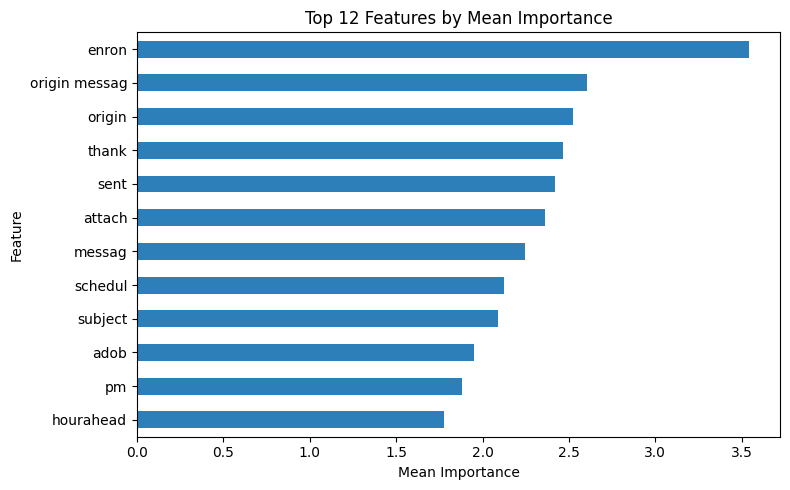

In [22]:
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names, name="rf_importance")
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names, name="xgb_importance")
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=feature_names, name="lr_importance")

importance_df = pd.concat([rf_importance, xgb_importance, lr_importance], axis=1).fillna(0.0)
importance_df["mean_importance"] = (
    importance_df["rf_importance"] + importance_df["xgb_importance"] + importance_df["lr_importance"]
) / 3

print("Top 20 combined features:")
display(importance_df.sort_values("mean_importance", ascending=False).head(20))

print("\nNumeric phishing signals (engineered features):")
display(importance_df.loc[numeric_cols].sort_values("mean_importance", ascending=False))

importance_df.sort_values("mean_importance", ascending=False).head(12).sort_values(
    "mean_importance"
)["mean_importance"].plot(kind="barh", figsize=(8, 5), color="#2c7fb8")
plt.title("Top 12 Features by Mean Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [23]:
from scipy.sparse import hstack
import pandas as pd

test_mails = [
    # Daha gerçekçi phishing
    """
    Subject: Microsoft Security Alert

    We detected an unusual sign-in attempt from a new device.
    If this activity was not performed by you, please review your account activity immediately.

    Review Activity:
    https://account-security-check365.com
    """,

    # Normal kurumsal mail ama phishing gibi görünebilir
    """
    Subject: VPN Access Expiring

    Hello team,

    Your VPN password will expire within 3 days.
    Please update your credentials using the employee portal before Friday.

    IT Department
    """,

    # Hafif şüpheli marketing mail
    """
    Subject: Exclusive Offer For Premium Users

    Dear customer,

    As one of our valued users, you are eligible for a limited-time upgrade offer.
    Visit our website for more details.

    Best regards,
    Customer Success Team
    """,

    # Gerçekçi spear-phishing tarzı
    """
    Subject: Updated Invoice - April

    Hi Ahmet,

    I attached the revised invoice we discussed earlier today.
    Please confirm the payment before 5 PM to avoid processing delays.

    Regards,
    Selin
    """,

    # Normal mail
    """
    Subject: Project Meeting Notes

    Hi everyone,

    Attached are the meeting notes and action items from today's sprint review.
    Let me know if anything is missing.

    Thanks,
    Mehmet
    """,

    # HTML / link ağırlıklı phishing
    """
    Subject: Payroll Update Required

    Dear Employee,

    Due to recent payroll system upgrades, employees must reconfirm their banking information.

    <a href="http://secure-payroll-update.com">Update Payroll Information</a>

    Failure to complete verification may result in delayed salary payments.
    """,

    # Kısa ama manipülatif
    """
    Subject: Are you available?

    Hey,

    I need you to purchase 5 gift cards for a client meeting today.
    Send me the codes once completed.

    Sent from my iPhone
    """
]

# ---------------------------
# DATAFRAME
# ---------------------------

test_df = pd.DataFrame({
    "subject": ["" for _ in test_mails],
    "body": test_mails
})

# ---------------------------
# PREPROCESSING
# ---------------------------

test_df["subject"] = test_df["subject"].fillna("").astype(str)
test_df["body"] = test_df["body"].fillna("").astype(str)

raw_text = test_df["subject"] + " " + test_df["body"]

test_df["subject_exclamation_count"] = test_df["subject"].str.count("!")
test_df["body_exclamation_count"] = test_df["body"].str.count("!")

test_df["exclamation_count"] = (
    test_df["subject_exclamation_count"]
    + test_df["body_exclamation_count"]
)

test_df["url_count"] = test_df["body"].str.count(url_pattern)

test_df["contains_urgent_word"] = raw_text.apply(
    contains_urgent_keyword
)

test_df["body_len"] = test_df["body"].str.len()

test_df["is_html"] = test_df["body"].str.contains(
    html_pattern,
    regex=True
).astype(int)

# ---------------------------
# CLEAN TEXT
# ---------------------------

test_df["subject_clean"] = test_df["subject"].apply(clean_text)
test_df["body_clean"] = test_df["body"].apply(clean_text)

test_df["text_clean"] = (
    test_df["subject_clean"] + " " + test_df["body_clean"]
).str.strip()

# ---------------------------
# TF-IDF
# ---------------------------

X_text = tfidf.transform(test_df["text_clean"])

# ---------------------------
# EXTRA FEATURES
# ---------------------------

extra_features = test_df[
    [
        "url_count",
        "contains_urgent_word",
        "body_len",
        "is_html",
        "exclamation_count"
    ]
]

# ---------------------------
# FINAL MATRIX
# ---------------------------

X_test = hstack([X_text, extra_features])

# ---------------------------
# PREDICTIONS
# ---------------------------

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)
lr_preds = lr_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
lr_probs = lr_model.predict_proba(X_test)[:, 1]

label_map = {
    0: "Normal",
    1: "Phishing"
}

# ---------------------------
# RESULTS TABLE 
# ---------------------------

pd.set_option("display.max_colwidth", None)

results_df = pd.DataFrame({
    "mail": [mail.strip() for mail in test_mails],

    "rf_prediction": [label_map[x] for x in rf_preds],
    "rf_probability": rf_probs.round(3),

    "xgb_prediction": [label_map[x] for x in xgb_preds],
    "xgb_probability": xgb_probs.round(3),

    "lr_prediction": [label_map[x] for x in lr_preds],
    "lr_probability": lr_probs.round(3),
})

results_df

,mail,rf_prediction,rf_probability,xgb_prediction,xgb_probability,lr_prediction,lr_probability
0,"Subject: Microsoft Security Alert\n\n We detected an unusual sign-in attempt from a new device.\n If this activity was not performed by you, please review your account activity immediately.\n\n Review Activity:\n https://account-security-check365.com",Phishing,0.614,Phishing,0.780,Phishing,0.555
1,"Subject: VPN Access Expiring\n\n Hello team,\n\n Your VPN password will expire within 3 days.\n Please update your credentials using the employee portal before Friday.\n\n IT Department",Normal,0.419,Normal,0.031,Normal,0.092
2,"Subject: Exclusive Offer For Premium Users\n\n Dear customer,\n\n As one of our valued users, you are eligible for a limited-time upgrade offer.\n Visit our website for more details.\n\n Best regards,\n Customer Success Team",Phishing,0.686,Phishing,0.864,Phishing,0.939
3,"Subject: Updated Invoice - April\n\n Hi Ahmet,\n\n I attached the revised invoice we discussed earlier today.\n Please confirm the payment before 5 PM to avoid processing delays.\n\n Regards,\n Selin",Normal,0.250,Normal,0.001,Normal,0.012
4,"Subject: Project Meeting Notes\n\n Hi everyone,\n\n Attached are the meeting notes and action items from today's sprint review.\n Let me know if anything is missing.\n\n Thanks,\n Mehmet",Normal,0.183,Normal,0.000,Normal,0.000
5,"Subject: Payroll Update Required\n\n Dear Employee,\n\n Due to recent payroll system upgrades, employees must reconfirm their banking information.\n\n <a href=""http://secure-payroll-update.com"">Update Payroll Information</a>\n\n Failure to complete verification may result in delayed salary payments.",Phishing,0.555,Phishing,0.587,Phishing,0.677
6,"Subject: Are you available?\n\n Hey,\n\n I need you to purchase 5 gift cards for a client meeting today.\n Send me the codes once completed.\n\n Sent from my iPhone",Normal,0.460,Normal,0.117,Normal,0.080


In [24]:
from transformers import pipeline

# Endüstride çok yaygın kullanılan, phishing odaklı eğitilmiş bir model seçiyoruz
# Bu model 'distilbert' tabanlıdır; hızlıdır ve bağlamı çok iyi anlar.
phishing_detector = pipeline("text-classification", 
                             model="ealvaradob/bert-finetuned-phishing", 
                             device=0) # device=0 GPU kullanmasını sağlar

def industrial_phishing_test(text):
    result = phishing_detector(text)[0]
    label = result['label']
    score = result['score']
    
    # Modelin çıktılarını daha anlaşılır yapalım
    # (Model etiketleri eğitim setine göre 'LABEL_0', 'LABEL_1' veya 'phishing' olabilir)
    print(f"Metin: {text[:100]}...")
    print(f"Sonuç: {label} (Güven Skoru: %{score*100:.2f})")
    print("-" * 30)

# Zorlayıcı test örnekleri
test_cases = [
    "Your account has been compromised. Please click here to reset your password immediately.",
    "Hey, are we still meeting for coffee at 5 PM today?",
    "Update regarding your recent order #12345. No action is needed at this time."
]

for case in test_cases:
    industrial_phishing_test(case)

config.json:   0%|          | 0.00/845 [00:00<?, ?B/s]

c:\Users\msozg\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\msozg\.cache\huggingface\hub\models--ealvaradob--bert-finetuned-phishing. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Metin: Your account has been compromised. Please click here to reset your password immediately....
Sonuç: phishing (Güven Skoru: %99.99)
------------------------------
Metin: Hey, are we still meeting for coffee at 5 PM today?...
Sonuç: benign (Güven Skoru: %100.00)
------------------------------
Metin: Update regarding your recent order #12345. No action is needed at this time....
Sonuç: benign (Güven Skoru: %99.99)
------------------------------


In [26]:
for case in test_mails:
    industrial_phishing_test(case)

Metin: 
    Subject: Microsoft Security Alert

    We detected an unusual sign-in attempt from a new device...
Sonuç: benign (Güven Skoru: %99.27)
------------------------------
Metin: 
    Subject: VPN Access Expiring

    Hello team,

    Your VPN password will expire within 3 days....
Sonuç: benign (Güven Skoru: %100.00)
------------------------------
Metin: 
    Subject: Exclusive Offer For Premium Users

    Dear customer,

    As one of our valued users,...
Sonuç: phishing (Güven Skoru: %100.00)
------------------------------
Metin: 
    Subject: Updated Invoice - April

    Hi Ahmet,

    I attached the revised invoice we discusse...
Sonuç: benign (Güven Skoru: %100.00)
------------------------------
Metin: 
    Subject: Project Meeting Notes

    Hi everyone,

    Attached are the meeting notes and action...
Sonuç: benign (Güven Skoru: %100.00)
------------------------------
Metin: 
    Subject: Payroll Update Required

    Dear Employee,

    Due to recent payroll system upgra